# 02 - Baseline Model on Raw (Dirty) Data

Purpose: Establish a performance baseline *before* any cleaning or feature engineering.  
We do the absolute minimum to avoid a crash (drop rows where the target is missing),  
but touch nothing else - missing values, wrong types, inconsistencies all stay in.

These scores are our reference point. Every later notebook should beat them.

Model: Linear Regression  
Target: `zero_hundred_stock` (0–100 km/h time in seconds)  
Data: `cars` table, raw CSV - 2,150 rows, no cleaning applied

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

cars = pd.read_csv('../data/raw/cars_raw.csv')
print(f"Raw shape: {cars.shape}")
cars.head(3)

Raw shape: (2150, 23)


,car_id,make,model,variant,raw_title,year_from,year_to,displacement_cc,cylinders,stock_hp,...,transmission,engine_type,fuel_type,drag_coef,frontal_area_m2,top_speed_stock,top_speed_mph,zero_hundred_stock,co2_gkm,source_url
0,CAR_91E03531,Audi,100,18 4d (83),Audi 100 Saloon1.8 4d (83) Specs & dimensions,1982,NaN,1781.0,NaN,90.0,...,Manual,Naturally Aspirated,Petrol,NaN,NaN,NaN,NaN,NaN,NaN,https://www.parkers.co.uk/audi/100/saloon-1982...
1,CAR_52A1021A,Audi,100,18 5d,Audi 100 Avant1.8 5d Specs & dimensions,1983,NaN,1781.0,NaN,90.0,...,Manual,Naturally Aspirated,Petrol,NaN,NaN,NaN,NaN,NaN,NaN,https://www.parkers.co.uk/audi/100/avant-1983/...
2,CAR_98F1457E,Audi,100,20e 4d,Audi 100 Saloon2.0E 4d Specs & dimensions,1991,NaN,1984.0,NaN,115.0,...,Manual,Naturally Aspirated,Petrol,NaN,NaN,NaN,NaN,NaN,NaN,https://www.parkers.co.uk/audi/100/saloon-1991...


## 1. What the raw data looks like - nulls and all

In [7]:
print("Null counts:")
print(cars.isnull().sum())
print(f"\nRows with ANY null: {cars.isnull().any(axis=1).sum()} / {len(cars)}")
print(f"\nCells that are null: {cars.isnull().sum().sum()}")

Null counts:
car_id                   0
make                     0
model                    0
variant                  0
raw_title                0
year_from                0
year_to               2078
displacement_cc        191
cylinders              598
stock_hp               127
stock_torque_nm        470
weight_kg              486
drivetrain              43
transmission            43
engine_type              0
fuel_type               43
drag_coef             2150
frontal_area_m2       2150
top_speed_stock        447
top_speed_mph          447
zero_hundred_stock     454
co2_gkm                464
source_url               0
dtype: int64

Rows with ANY null: 2150 / 2150

Cells that are null: 10191


## 2. Minimum viable preprocessing

We only do what's strictly necessary to not crash:
- Drop rows where the target (`zero_hundred_stock`) is missing
- Drop rows where ALL selected features are missing
- Encode categorical columns as numeric codes (no thought given to whether that's meaningful)

Everything else - remaining NaNs, outliers, wrong units - stays raw.

In [8]:
FEATURES = ['stock_hp', 'weight_kg', 'displacement_cc', 'cylinders',
            'drivetrain', 'engine_type', 'fuel_type']
TARGET = 'zero_hundred_stock'

df = cars[FEATURES + [TARGET]].copy()

# Minimum: drop rows with missing target
df = df.dropna(subset=[TARGET])
print(f"After dropping missing target: {len(df)} rows")

# Encode categoricals as integer codes — crude but fast
for col in ['drivetrain', 'engine_type', 'fuel_type']:
    df[col] = pd.Categorical(df[col]).codes  # NaN becomes -1

# Fill remaining numeric NaNs with column median (bare minimum to not crash)
df = df.fillna(df.median(numeric_only=True))

print(f"Remaining nulls: {df.isnull().sum().sum()}")
print(f"\nFeature dtypes:")
print(df.dtypes)

After dropping missing target: 1696 rows
Remaining nulls: 0

Feature dtypes:
stock_hp              float64
weight_kg             float64
displacement_cc       float64
cylinders             float64
drivetrain               int8
engine_type              int8
fuel_type                int8
zero_hundred_stock    float64
dtype: object


## 3. Train and evaluate

In [9]:
X = df[FEATURES].values
y = df[TARGET].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

mae   = mean_absolute_error(y, y_pred)
r2    = r2_score(y, y_pred)

# Cross-validated MAE (5-fold) — more honest than train-set MAE
cv_mae = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error').mean()

print("=== DIRTY BASELINE SCORES ===")
print(f"Train MAE  : {mae:.3f} sec")
print(f"CV MAE     : {cv_mae:.3f} sec   ← the honest number")
print(f"R²         : {r2:.3f}")
print()
print("Save these — we compare against them after cleaning + feature engineering.")

# Persist the baseline so later notebooks read it instead of hardcoding
import json, os
os.makedirs('../data/interim', exist_ok=True)
with open('../data/interim/baseline_scores.json', 'w') as _f:
    json.dump({'dirty_cv_mae': round(cv_mae, 4), 'dirty_r2': round(r2, 4),
               'n_rows': int(len(df))}, _f)
print(f'Saved baseline ({len(df)} rows) -> data/interim/baseline_scores.json')

=== DIRTY BASELINE SCORES ===
Train MAE  : 1.336 sec
CV MAE     : 1.436 sec   ← the honest number
R²         : 0.724

Save these — we compare against them after cleaning + feature engineering.
Saved baseline (1696 rows) -> data/interim/baseline_scores.json


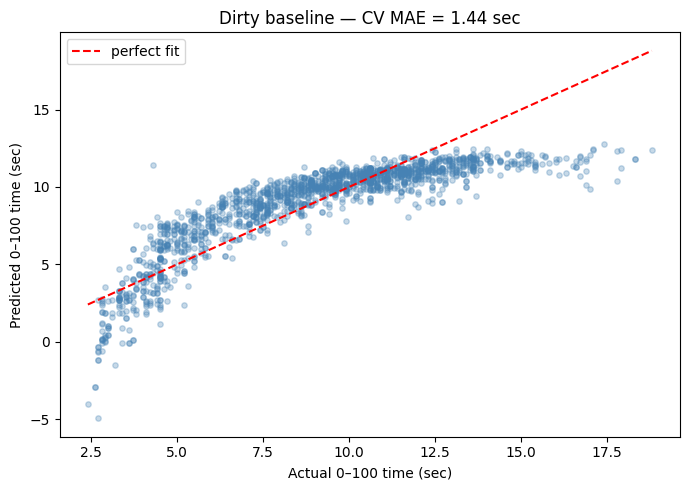

Plot saved → docs/baseline_dirty.png


In [10]:
# Visualise: predicted vs actual
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y, y_pred, alpha=0.3, s=15, color='steelblue')
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=1.5, label='perfect fit')
ax.set_xlabel('Actual 0–100 time (sec)')
ax.set_ylabel('Predicted 0–100 time (sec)')
ax.set_title(f'Dirty baseline — CV MAE = {cv_mae:.2f} sec')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/baseline_dirty.png', dpi=120)
plt.show()
print("Plot saved → docs/baseline_dirty.png")

In [6]:
# Feature importance (coefficients) — don't read too much into this on dirty data
coef_df = pd.DataFrame({'feature': FEATURES, 'coefficient': model.coef_})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)
print("Coefficients (dirty data):")
print(coef_df.to_string(index=False))

Coefficients (dirty data):
        feature  coefficient
     drivetrain    -0.374253
      cylinders     0.316242
      fuel_type    -0.063309
    engine_type     0.041704
       stock_hp    -0.018384
      weight_kg    -0.000799
displacement_cc    -0.000203


---
## Summary

| Metric | Dirty baseline |
|--------|----------------|
| CV MAE | 1.436 sec      |
| R² | 0.724          |

This is our floor. After notebook `03_cleaning` and `04_features`, we expect CV MAE to drop  
and R² to rise - that improvement is the main story of the presentation.